In [118]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

### Normal

In [119]:
def psi(x):
    return stats.norm.pdf(x) / (1 - stats.norm.cdf(x))


def first_moment(mu, sigma, a):
    alpha = (a - mu) / sigma
    return mu + sigma * psi(alpha)


def second_moment(mu, sigma, a):
    alpha = (a - mu) / sigma
    return mu**2 + sigma**2 + sigma * psi(alpha) * (2 * mu + sigma * alpha)

In [120]:
n_iter = 50
mu_true = 5
sigma_true = 2
a = 4
n = 10000
x = stats.norm.rvs(size=n, loc=mu_true, scale=sigma_true)

mus = []
sigmas = []

mu = x[x < a].mean()
mus.append(mu)

sigma = x[x < a].std()
sigmas.append(sigma)

for _ in range(n_iter):
    u = np.where(x < a, x, first_moment(mu, sigma, a))
    v = np.where(x < a, x**2, second_moment(mu, sigma, a))

    mu = u.mean()
    mus.append(mu)

    sigma = np.sqrt(v.mean() - mu**2)
    sigmas.append(sigma)

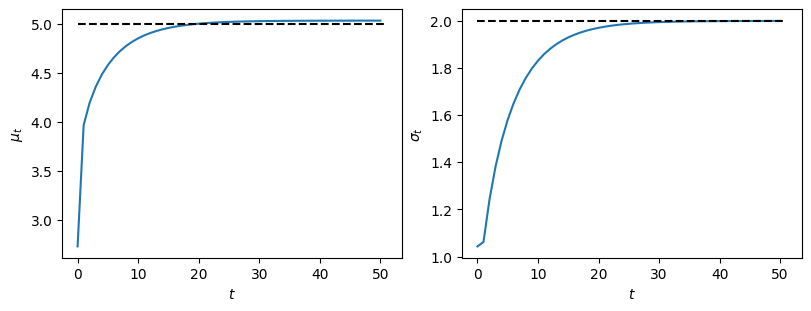

In [121]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 3), layout="constrained")

axes[0].plot(mus)
axes[0].set_xlabel("$t$")
axes[0].set_ylabel("$\\mu_t$")
axes[0].plot([0, n_iter + 1], [mu_true, mu_true], "k--")

axes[1].plot(sigmas)
axes[1].set_xlabel("$t$")
axes[1].set_ylabel("$\\sigma_t$")
axes[1].plot([0, n_iter + 1], [sigma_true, sigma_true], "k--")
plt.show()

### Exponential

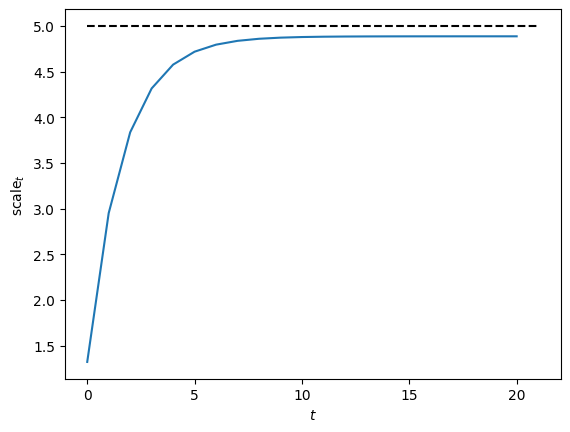

In [190]:
n_iter = 20
scale_true = 5
a = 3
n = 1000
x = stats.expon.rvs(size=n, scale=scale_true)

scales = []
scale = x[x < a].mean()
scales.append(scale)

for _ in range(n_iter):
    u = np.where(x < a, x, a + scale)
    scale = u.mean()
    scales.append(scale)

plt.plot(scales)
plt.plot([0, n_iter + 1], [scale_true, scale_true], "k--")
plt.xlabel("$t$")
plt.ylabel("$\\operatorname{scale}_t$")
plt.show()